In [58]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [59]:
DATA_PATH = os.path.join('..', 'data', 'processed', 'ncr_properties_cleaned.parquet')

# Load the Parquet file
df = pd.read_parquet(DATA_PATH)

print(f"✅ Loaded {len(df)} rows from Parquet.")
df.sample()

✅ Loaded 12324 rows from Parquet.


,title,url,city,location,price,price_raw,area,area_raw,bedrooms,bathrooms,...,gym,lift,parking,vastu_compliant,property_hash,scraped_at,society_name,sector,locality,price_per_sqft
6220,"3 BHK Flat for Sale in Parsvnath Panorama, ...",https://www.magicbricks.com/propertyDetails/3-...,Greater Noida,Unknown,27000000,₹2.70 Cr₹11097 per sqft,2433.0,,3,0,...,0,0,0,0,82fb4c6bd4dd0ed92cee7e1902905286,2026-02-02 15:39:51.850352,Independent/Authority,Parsvnath Panorama,Greater Noida,11097.0


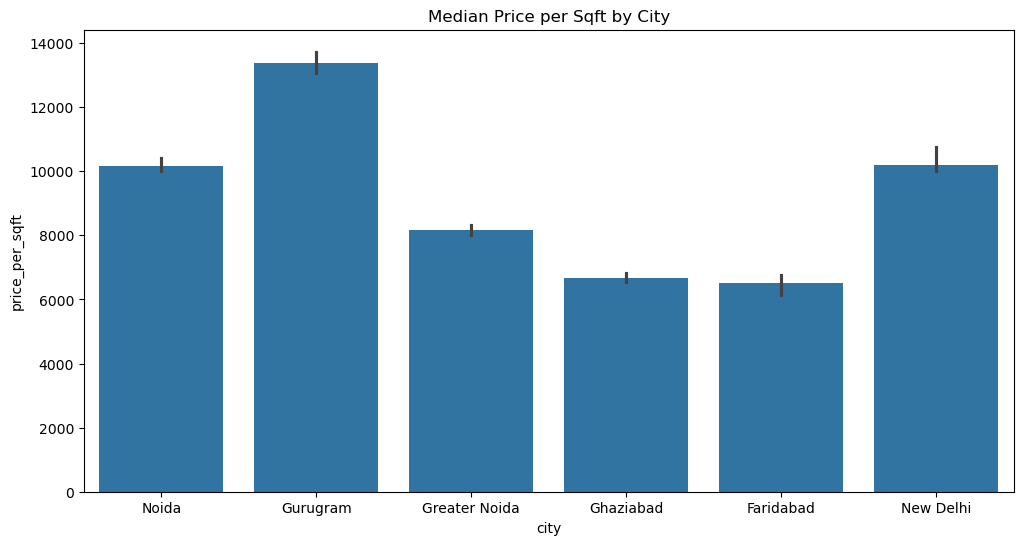

In [60]:
plt.figure(figsize=(12, 6))
sns.barplot(x='city', y='price_per_sqft', data=df, estimator='median')
plt.title('Median Price per Sqft by City')
plt.show()

<Axes: xlabel='area', ylabel='price'>

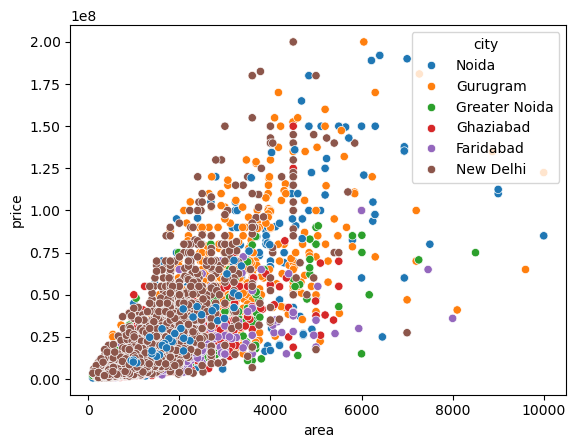

In [61]:
sns.scatterplot(x='area', y='price', hue='city', data=df)

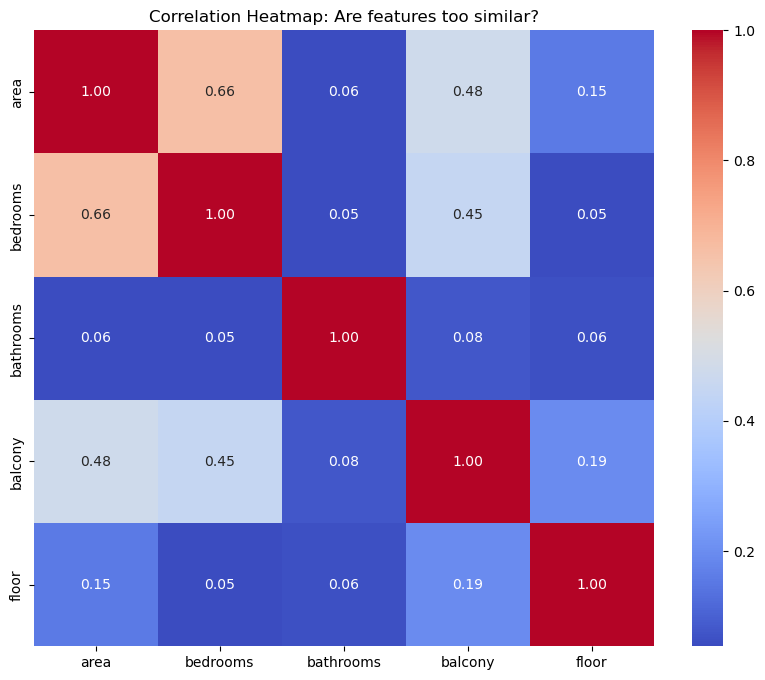


--- Variance Inflation Factor (VIF) ---
     feature       VIF
1   bedrooms  7.640443
0       area  7.119323
3    balcony  4.011690
4      floor  1.185949
2  bathrooms  1.046964


In [62]:
# . Select numerical features for the model
# We exclude 'price_per_sqft' because it's derived from our target (price)
features = ['area', 'bedrooms', 'bathrooms', 'balcony', 'floor']
X = df[features].fillna(0) # Ensure no NaNs for the math

# 3. Correlation Heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap: Are features too similar?")
plt.show()

# 4. Variance Inflation Factor (VIF)
# VIF > 5-10 indicates high multicollinearity
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print("\n--- Variance Inflation Factor (VIF) ---")
print(vif_data.sort_values(by="VIF", ascending=False))

In [63]:
# TEMPORARY CLEANING FOR EDA ACCURACY
# We drop these now so our graphs represent the true market, not the spam.
df = df.drop_duplicates(subset=['city', 'sector', 'price', 'area'], keep='first')
print(f"EDA Dataset: {len(df)} unique rows remaining.")

EDA Dataset: 10538 unique rows remaining.


In [99]:
# 3. Investigation: The "Hidden Null" Check
# We suspect '0' is used as a placeholder for missing data.
zero_bath_count = (df['bathrooms'] == 0).sum()
zero_bed_count = (df['bedrooms'] == 0).sum()

print(f"Properties with 0 Bathrooms: {zero_bath_count} ({round(zero_bath_count/len(df)*100, 1)}%)")
print(f"Properties with 0 Bedrooms: {zero_bed_count} ({round(zero_bed_count/len(df)*100, 1)}%)")

Properties with 0 Bathrooms: 10051 (95.4%)
Properties with 0 Bedrooms: 143 (1.4%)


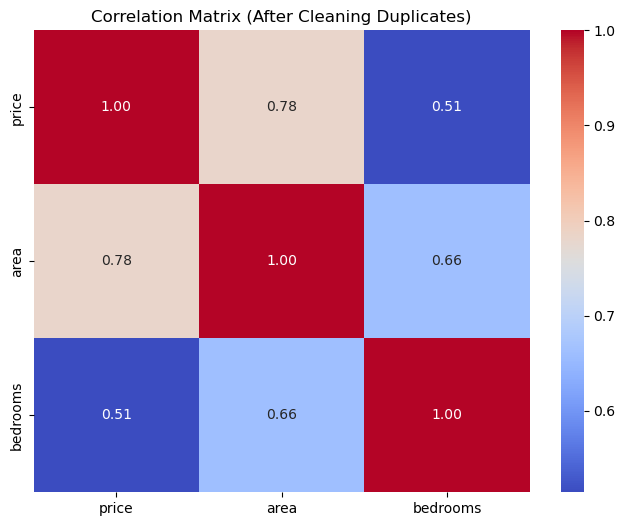

In [101]:
# 4. Correlation Analysis (on Clean Data)
# We only check 'Area' and 'Bedrooms' since 'Bathrooms' is broken.
plt.figure(figsize=(8, 6))
sns.heatmap(df[['price', 'area', 'bedrooms']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix (After Cleaning Duplicates)')
plt.show()

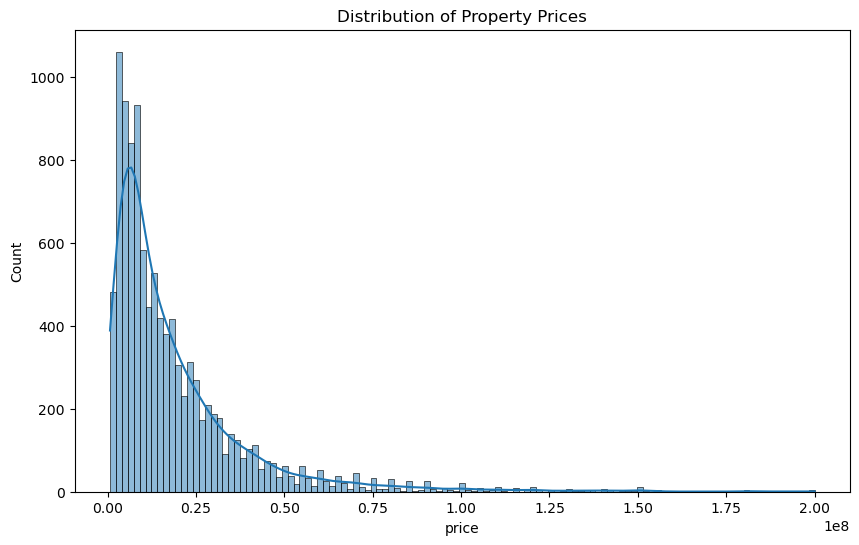

In [64]:
plt.figure(figsize=(10,6))
sns.histplot(df['price'], kde=True)
plt.title('Distribution of Property Prices')
plt.show()

# If the graph looks like a "mountain" pushed to the left, 
# we will use np.log(df['price']) to make regression more accurate.

Original Skewness: 2.98


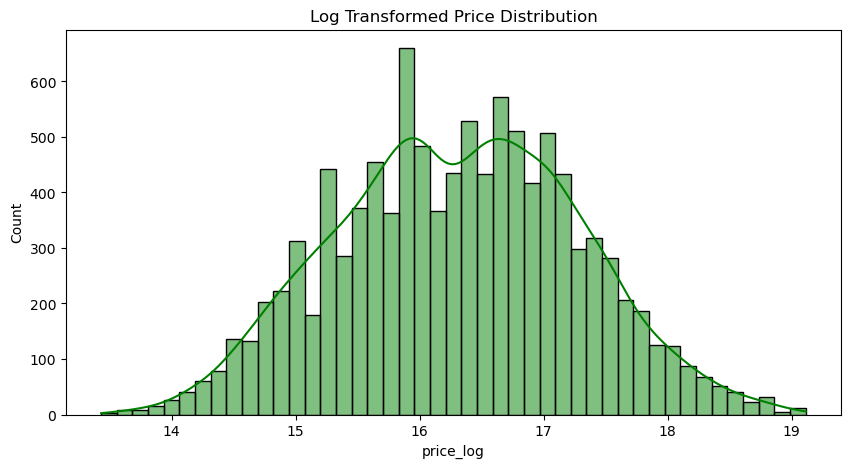

New Skewness: 0.00


In [65]:
# 1. original Price skew
print(f"Original Skewness: {df['price'].skew():.2f}")

# 2. Log Transformation (We use log1p to handle any 0s, though prices won't be 0)
df['price_log'] = np.log1p(df['price'])

# 3. new distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['price_log'], kde=True, color='green', edgecolor='black')
plt.title('Log Transformed Price Distribution')
plt.show()

print(f"New Skewness: {df['price_log'].skew():.2f}")

In [66]:
def analyze_outliers_iqr(df, col):
    # 1. Calculate IQR Stats
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # 2. Define standard (1.5x) and extreme (3x) bounds
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    extreme_upper = Q3 + 3.0 * IQR # "Extreme" outliers
    
    # 3. Print the Summary
    print(f"--- Statistical Summary for {col} ---")
    print(f"Interquartile Range (IQR): {IQR:.2f}")
    print(f"Standard Upper Bound (1.5x): {upper_fence:.2f}")
    print(f"Extreme Upper Bound (3.0x): {extreme_upper:.2f}")
    
    # 4. Count the outliers
    outliers = df[df[col] > upper_fence]
    extreme_outliers = df[df[col] > extreme_upper]
    
    print(f"Total Outliers (> 1.5x): {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
    print(f"Extreme Outliers (> 3.0x): {len(extreme_outliers)} ({len(extreme_outliers)/len(df)*100:.1f}%)")
    print("-" * 35)
    
    return outliers

# Run the analysis for Price and Area
price_outliers = analyze_outliers_iqr(df, 'price')
area_outliers = analyze_outliers_iqr(df, 'area')

--- Statistical Summary for price ---
Interquartile Range (IQR): 18500000.00
Standard Upper Bound (1.5x): 52250000.00
Extreme Upper Bound (3.0x): 80000000.00
Total Outliers (> 1.5x): 676 (6.4%)
Extreme Outliers (> 3.0x): 238 (2.3%)
-----------------------------------
--- Statistical Summary for area ---
Interquartile Range (IQR): 970.00
Standard Upper Bound (1.5x): 3325.00
Extreme Upper Bound (3.0x): 4780.00
Total Outliers (> 1.5x): 455 (4.3%)
Extreme Outliers (> 3.0x): 121 (1.1%)
-----------------------------------


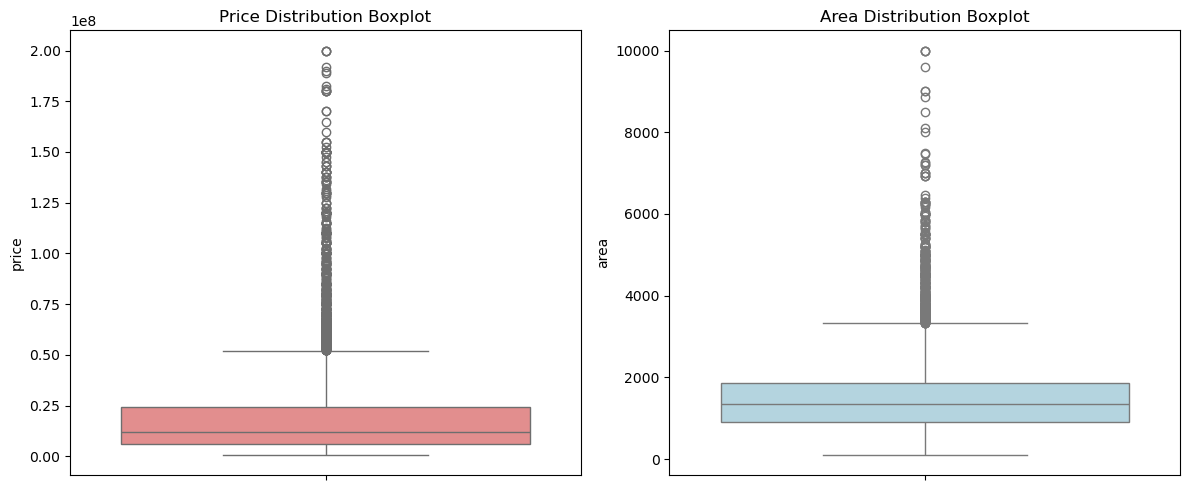

In [67]:

plt.figure(figsize=(12, 5))

# Plotting Price Distribution with Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(y=df['price'], color='lightcoral')
plt.title('Price Distribution Boxplot')

# Plotting Area Distribution with Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(y=df['area'], color='lightblue')
plt.title('Area Distribution Boxplot')

plt.tight_layout()
plt.show()

In [68]:
# mask for properties that are extreme in both price and area
extreme_mask = (df['price'] > 8.14) & (df['area'] > 4667)
both_extreme = df[extreme_mask]

print(f"Properties extreme in both Price & Area: {len(both_extreme)}")

# most suspicious ones (Small Area but Massive Price)
suspicious = df[(df['area'] < 1000) & (df['price'] > 2.0)]
print("\nSuspicious Properties (Tiny Area, High Price):")
print(suspicious[['city', 'sector', 'price', 'area']].head())

Properties extreme in both Price & Area: 135

Suspicious Properties (Tiny Area, High Price):
      city           sector     price   area
24   Noida       Sector 120  10900000  943.0
32   Noida  Noida Extension  11200000  995.0
39   Noida  Noida Extension  10100000  988.0
122  Noida  Noida Extension   3500000  900.0
128  Noida         Sarfabad   4300000  800.0


In [69]:
# Checking for duplicates based on the core features only
feature_duplicates = df.duplicated(subset=['city', 'sector', 'price', 'area']).sum()
print(f"Duplicates based on core features: {feature_duplicates}")

# Let's see an example of these 'near-duplicates'
if feature_duplicates > 0:
    print("\nExample of Feature-Level Duplicates:")
    print(df[df.duplicated(subset=['city', 'sector', 'price', 'area'], keep=False)].sort_values(by='price').head(4))

Duplicates based on core features: 0


In [70]:
# How many unique sectors per city?
print(df_unique.groupby('city')['sector'].nunique())

# Top 10 most frequent sectors (Where is our data concentrated?)
print("\nMost frequent sectors in the dataset:")
print(df_unique['sector'].value_counts().head(10))

city
Faridabad        102
Ghaziabad        192
Greater Noida    140
Gurugram         220
New Delhi        640
Noida            135
Name: sector, dtype: int64

Most frequent sectors in the dataset:
sector
Noida Extension        829
Indirapuram            285
Raj Nagar Extension    244
Sector 150             194
Yamuna Expressway      155
National Highway 24    151
Sector 79              137
Sector 49              126
Sector 107             124
Sector 43              117
Name: count, dtype: int64


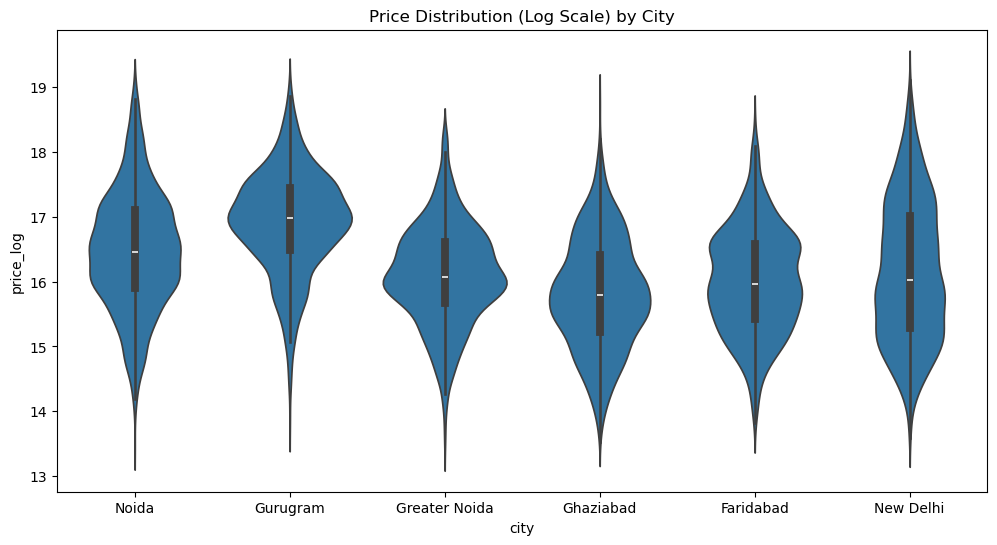

In [71]:
plt.figure(figsize=(12, 6))
sns.violinplot(x='city', y='price_log', data=df_unique)
plt.title('Price Distribution (Log Scale) by City')
plt.show()

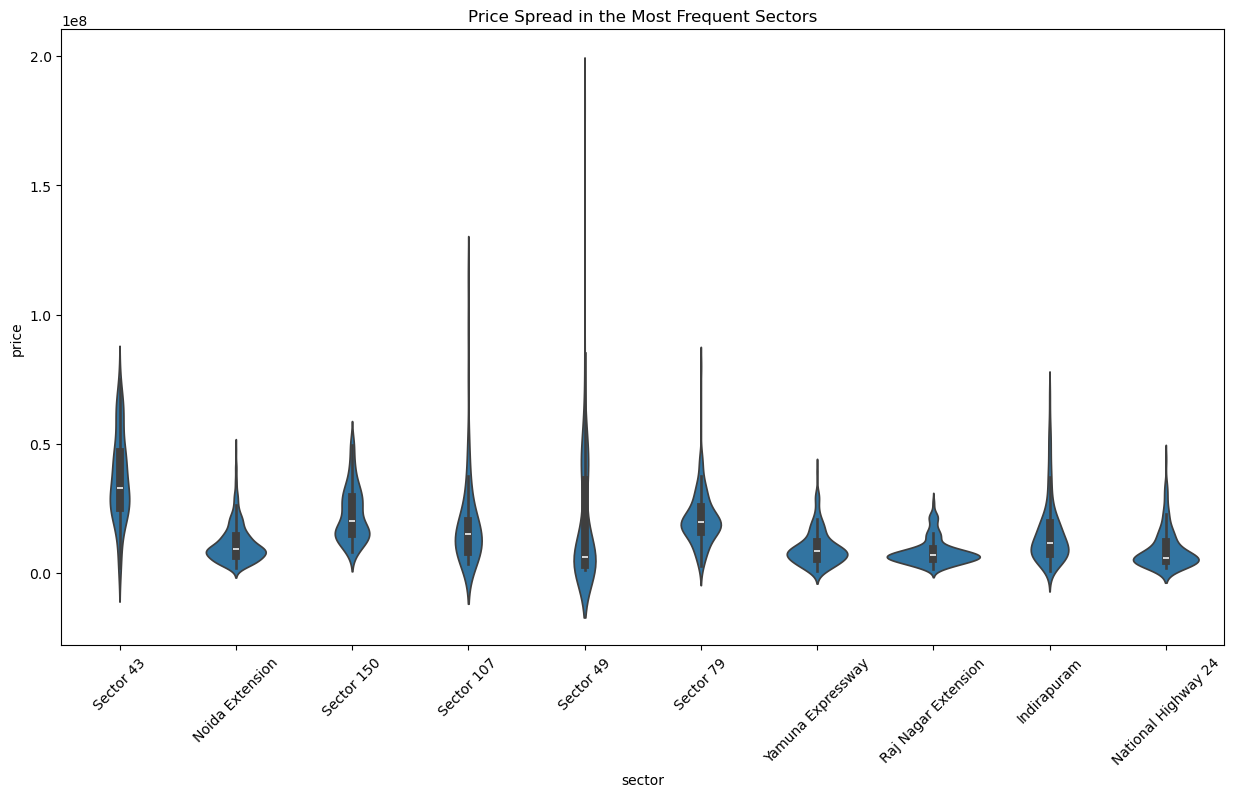

In [72]:
plt.figure(figsize=(15, 8))
# Filtering to only show the Top 10 Sectors for clarity
top_10_sectors = df_unique['sector'].value_counts().head(10).index
df_top_sectors = df_unique[df_unique['sector'].isin(top_10_sectors)]

sns.violinplot(x='sector', y='price', data=df_top_sectors)
plt.xticks(rotation=45)
plt.title('Price Spread in the Most Frequent Sectors')
plt.show()

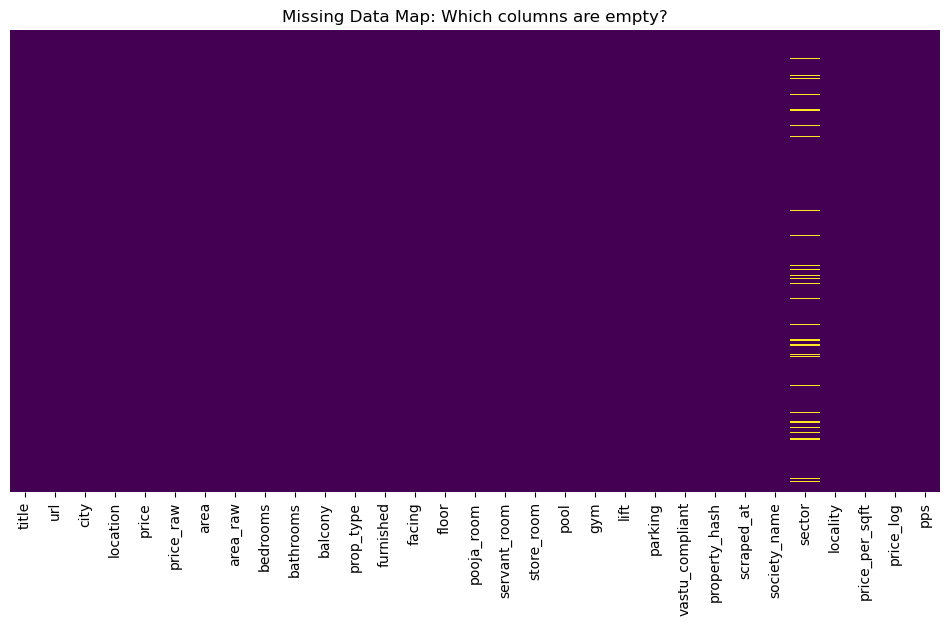


Null Value Counts:
sector             935
title                0
servant_room         0
price_log            0
price_per_sqft       0
locality             0
society_name         0
scraped_at           0
property_hash        0
vastu_compliant      0
parking              0
lift                 0
gym                  0
pool                 0
store_room           0
pooja_room           0
url                  0
floor                0
facing               0
furnished            0
prop_type            0
balcony              0
bathrooms            0
bedrooms             0
area_raw             0
area                 0
price_raw            0
price                0
location             0
city                 0
pps                  0
dtype: int64


In [73]:
plt.figure(figsize=(12, 6))
# Using isnull() to create a boolean map and visualizing it
sns.heatmap(df_unique.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Map: Which columns are empty?')
plt.show()

# Precise numbers
print("\nNull Value Counts:")
print(df_unique.isnull().sum().sort_values(ascending=False))

In [74]:
# Create a dataframe of rows where sector is null
missing_sector_df = df_unique[df_unique['sector'].isnull()]

print("--- Analysis of Missing Sectors ---")
print(f"Average Price of 'No Sector' properties: {missing_sector_df['price'].mean():.2f} Cr")
print(f"Top 5 Cities for missing sectors:\n{missing_sector_df['city'].value_counts()}")

# Check if 'locality' has info we can use to fill 'sector'
print(f"\nExample Localities where Sector is missing:\n{missing_sector_df['locality'].head()}")

--- Analysis of Missing Sectors ---
Average Price of 'No Sector' properties: 15369304.81 Cr
Top 5 Cities for missing sectors:
city
New Delhi        336
Greater Noida    161
Ghaziabad        149
Noida            142
Gurugram          95
Faridabad         52
Name: count, dtype: int64

Example Localities where Sector is missing:
44     Noida
92     Noida
267    Noida
298    Noida
307    Noida
Name: locality, dtype: object


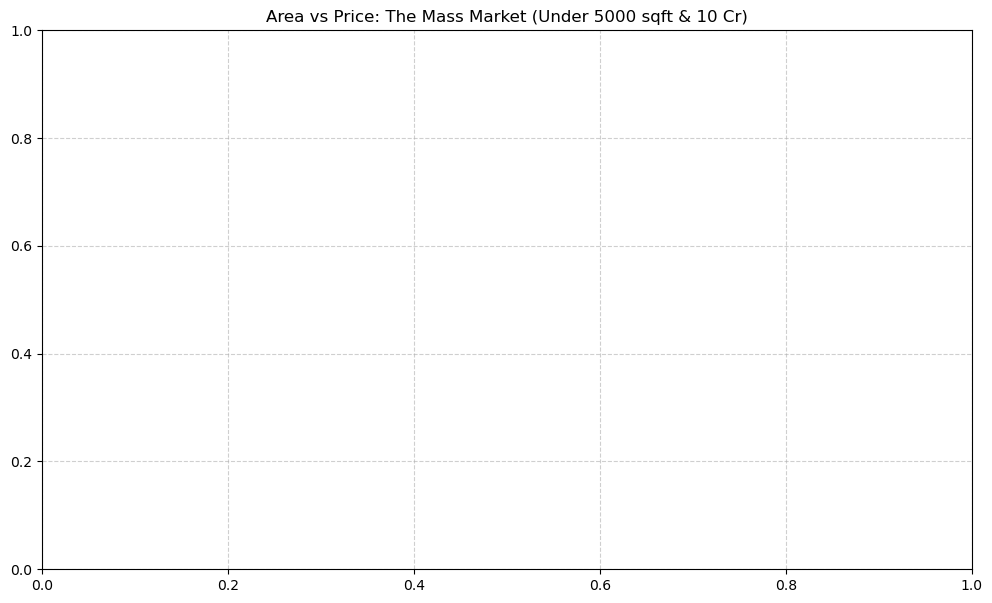

In [75]:
plt.figure(figsize=(12, 7))
# We filter to < 5000 sqft and < 10 Cr to see the 'Normal' market clearly
sns.scatterplot(data=df_unique[(df_unique['area'] < 5000) & (df_unique['price'] < 10)], 
                x='area', y='price', hue='city', alpha=0.4)

plt.title('Area vs Price: The Mass Market (Under 5000 sqft & 10 Cr)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

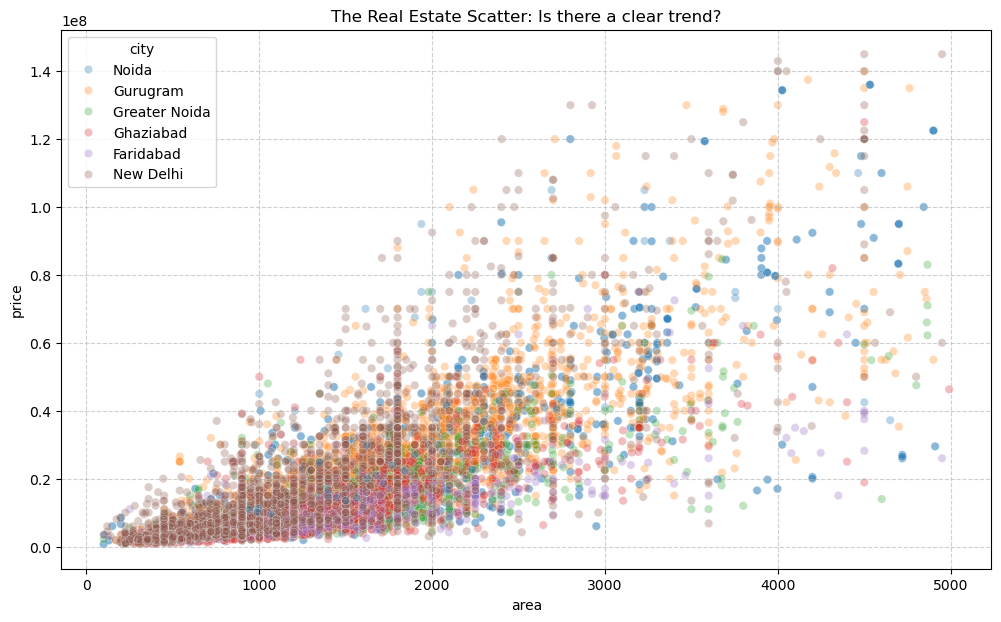

In [76]:
plt.figure(figsize=(12, 7))
# We filter to < 5000 sqft and < 15 Cr to see the 'Normal' market clearly
sns.scatterplot(data=df_unique[(df_unique['area'] < 5000) & (df_unique['price'] < 150000000)], 
                x='area', y='price', hue='city', alpha=0.3)

plt.title('The Real Estate Scatter: Is there a clear trend?')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [77]:
print(f"Properties with 0 bathrooms: {(df_unique['bathrooms'] == 0).sum()}")
print(f"Properties with 0 bedrooms: {(df_unique['bedrooms'] == 0).sum()}")

Properties with 0 bathrooms: 11783
Properties with 0 bedrooms: 180


In [78]:
# Check unique values for all amenity/room columns
cols_to_check = ['bathrooms', 'bedrooms', 'lift', 'parking', 'gym', 'pool', 'servant_room']

for col in cols_to_check:
    print(f"{col}: {df_unique[col].unique()}")

bathrooms: [0 3 6 2 4 5 7 1 8]
bedrooms: [ 3  5  4  2  0  1  7 10  6  8  9]
lift: [0 1]
parking: [0 1]
gym: [0 1]
pool: [0 1]
servant_room: [0 1]


C:\Users\Asus\AppData\Local\Temp\ipykernel_6676\2173220679.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='city', y='pps', data=df_unique, estimator='median', palette='magma')


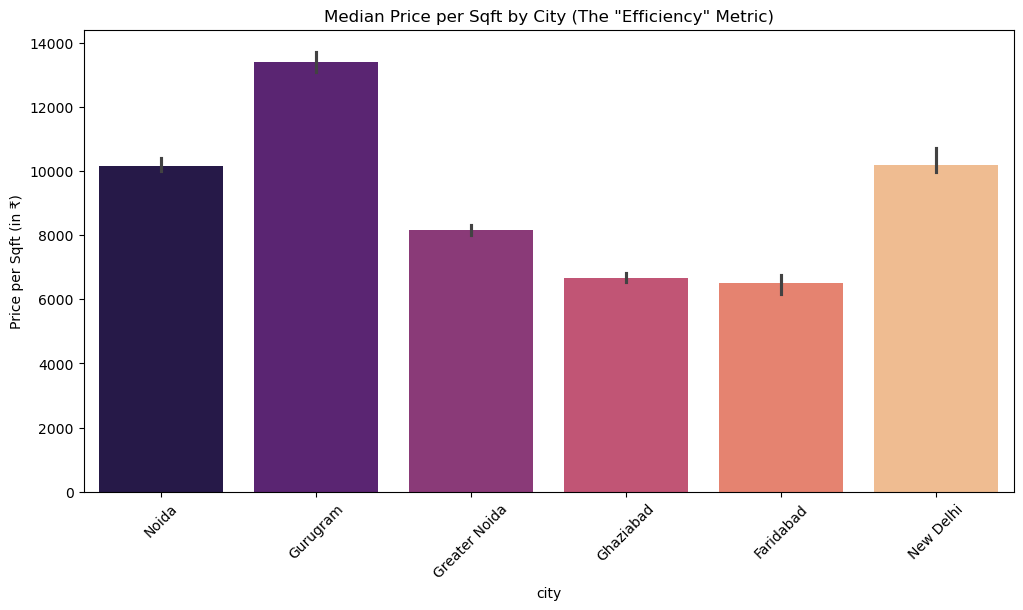

In [79]:
# Calculate Price per Sqft if not already done
df_unique['pps'] = df_unique['price'] / df_unique['area']

plt.figure(figsize=(12, 6))
sns.barplot(x='city', y='pps', data=df_unique, estimator='median', palette='magma')
plt.title('Median Price per Sqft by City (The "Efficiency" Metric)')
plt.ylabel('Price per Sqft (in ₹)')
plt.xticks(rotation=45)
plt.show()

In [80]:
# Correlation check on the rows that actually HAVE data (> 0)
has_data = df_unique[(df_unique['bathrooms'] > 0) & (df_unique['bedrooms'] > 0)]

print(f"Correlation (Area vs Price): {has_data['area'].corr(has_data['price']):.2f}")
print(f"Correlation (Bedrooms vs Price): {has_data['bedrooms'].corr(has_data['price']):.2f}")

Correlation (Area vs Price): 0.81
Correlation (Bedrooms vs Price): 0.58


C:\Users\Asus\AppData\Local\Temp\ipykernel_6676\939269086.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='city', y='pps', data=df_unique, estimator='median', palette='viridis')


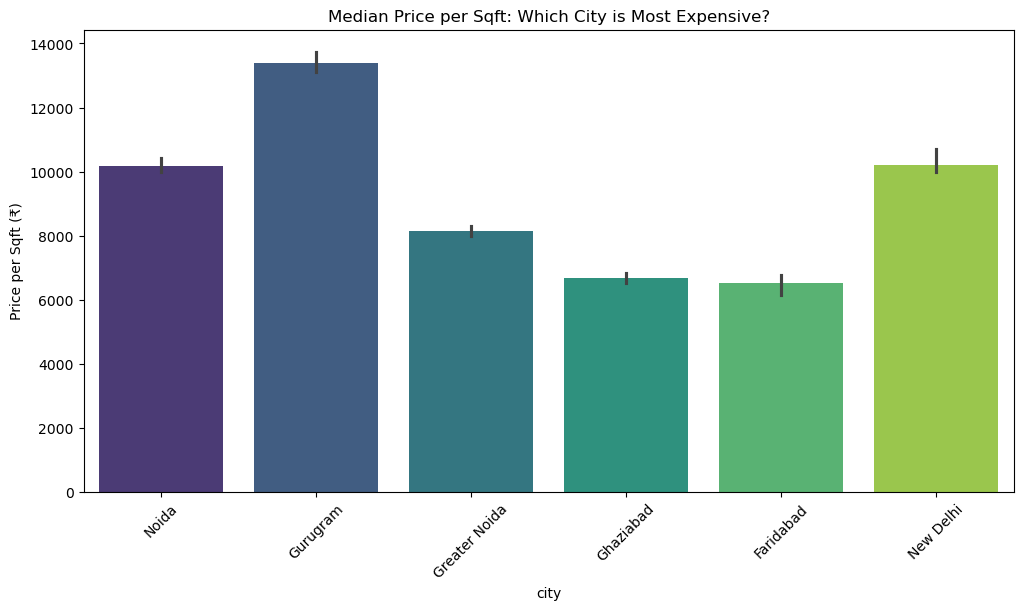

In [81]:
# Calculate Price per Sqft
df_unique['pps'] = df_unique['price'] / df_unique['area']

plt.figure(figsize=(12, 6))
# Median is better because of the outliers we found in Delhi
sns.barplot(x='city', y='pps', data=df_unique, estimator='median', palette='viridis')
plt.title('Median Price per Sqft: Which City is Most Expensive?')
plt.ylabel('Price per Sqft (₹)')
plt.xticks(rotation=45)
plt.show()

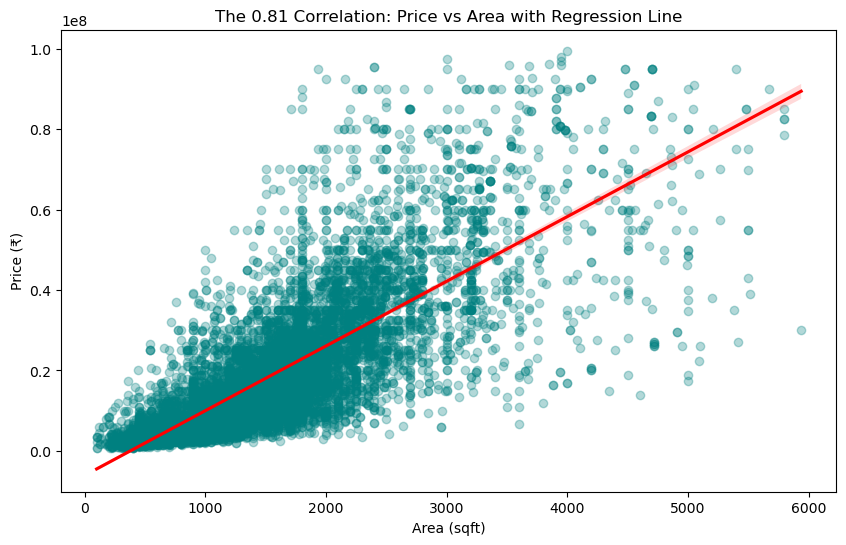

In [82]:
df_plot = df_unique[(df_unique['area'] < 6000) & (df_unique['price'] < 100000000)]

plt.figure(figsize=(10, 6))
sns.regplot(data=df_plot, x='area', y='price', 
            scatter_kws={'alpha':0.3, 'color':'teal'}, 
            line_kws={'color':'red'})

plt.title('The 0.81 Correlation: Price vs Area with Regression Line')
plt.xlabel('Area (sqft)')
plt.ylabel('Price (₹)')
plt.show()

In [83]:
print(f"Correlation (Area vs Bedrooms): {has_data['area'].corr(has_data['bedrooms']):.2f}")

Correlation (Area vs Bedrooms): 0.70


C:\Users\Asus\AppData\Local\Temp\ipykernel_6676\3486079502.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='bedrooms', y='price', data=df_unique[df_unique['bedrooms'] > 0], palette='magma')


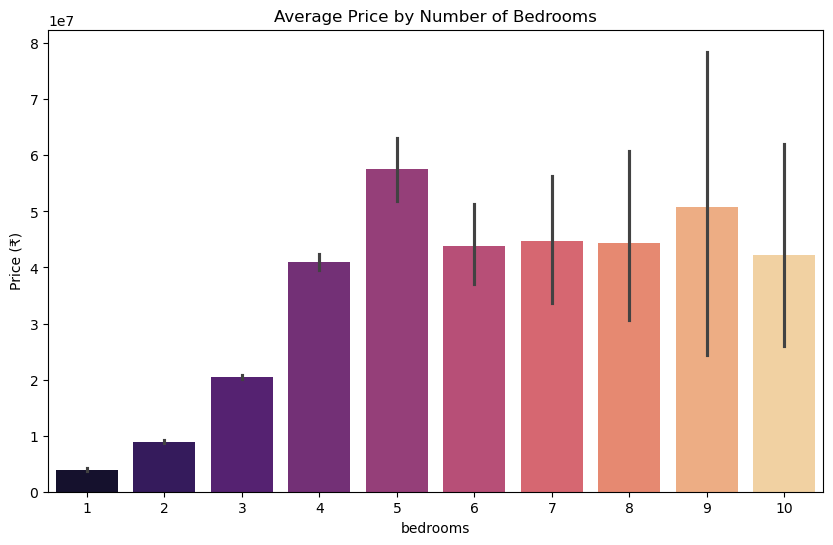

In [84]:


# the average price for different bedroom counts
plt.figure(figsize=(10, 6))
sns.barplot(x='bedrooms', y='price', data=df_unique[df_unique['bedrooms'] > 0], palette='magma')
plt.title('Average Price by Number of Bedrooms')
plt.ylabel('Price (₹)')
plt.show()

In [85]:
# 1. Calculate PPS if you haven't already
df['pps'] = df['price'] / df['area']

# 2. Group by Sector (Filtering for sectors with at least 5 listings for reliability)
sector_stats = df.groupby('sector').agg({
    'pps': 'mean',
    'price': 'count'
}).rename(columns={'price': 'listing_count'})

# 3. Get the Top 10 (Minimum 5 listings to avoid fluke data)
top_10_expensive = sector_stats[sector_stats['listing_count'] >= 5].sort_values(by='pps', ascending=False).head(10)

print("Top 10 Most Expensive Sectors (Price per Sqft):")
print(top_10_expensive)

Top 10 Most Expensive Sectors (Price per Sqft):
                             pps  listing_count
sector                                         
Defence Colony      38791.448190              6
Sector 41           34422.457937              7
Vasant Vihar        32773.678702              7
Greater Kailash 1   29955.509711             15
Golf Course Road    29869.231592              7
Greater Kailash 2   29435.982224             13
New Rajendra Nagar  29179.860938              5
Sector 54           28747.667026             16
Safdarjung Enclave  27752.645882             10
Hauz Khas           27181.085980             11


In [86]:
# Check variance in the most expensive sector
top_sector_name = top_10_expensive.index[0]
print(f"\nPrice variation in {top_sector_name}:")
print(df[df['sector'] == top_sector_name]['price'].describe())


Price variation in Defence Colony:
count    6.000000e+00
mean     1.084167e+08
std      4.452013e+07
min      5.500000e+07
25%      8.137500e+07
50%      1.027500e+08
75%      1.275000e+08
max      1.800000e+08
Name: price, dtype: float64


C:\Users\Asus\AppData\Local\Temp\ipykernel_6676\3721383795.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sector', y='pps', data=df_comp, palette='Set2')


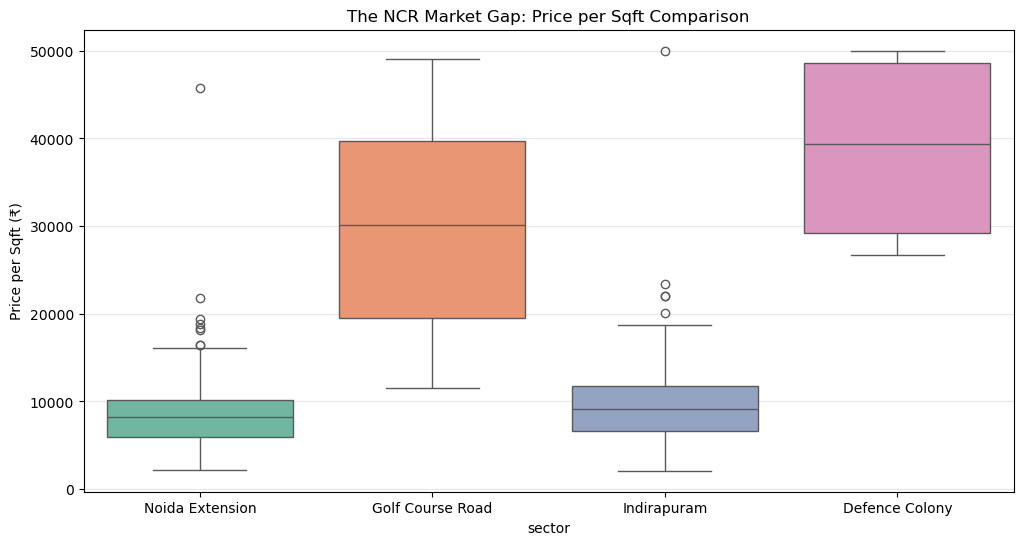

In [87]:
# Compare the "Volume King" vs the "Value King"
comparison_list = ['Noida Extension', 'Defence Colony', 'Golf Course Road', 'Indirapuram']
df_comp = df[df['sector'].isin(comparison_list)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='sector', y='pps', data=df_comp, palette='Set2')
plt.title('The NCR Market Gap: Price per Sqft Comparison')
plt.ylabel('Price per Sqft (₹)')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [88]:
# See if '0' floor properties are mostly houses or flats
print(df_unique[df_unique['floor'] == 0]['prop_type'].value_counts())

prop_type
Apartment            7846
Independent House    1648
Builder Floor         650
Plot                   77
Name: count, dtype: int64


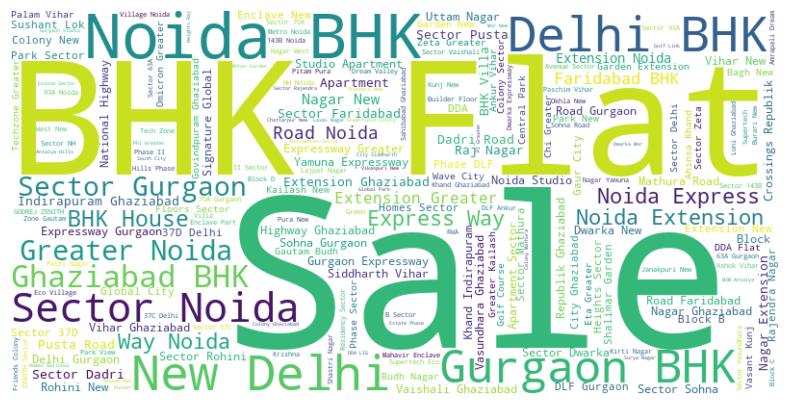

In [89]:
from wordcloud import WordCloud
# Visualize the most common words in property titles
text = " ".join(title for title in df_unique.title)
wordcloud = WordCloud(background_color="white", width=800, height=400).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_6676\338357485.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='prop_type', y='pps', data=df_unique, estimator='median', palette='viridis')


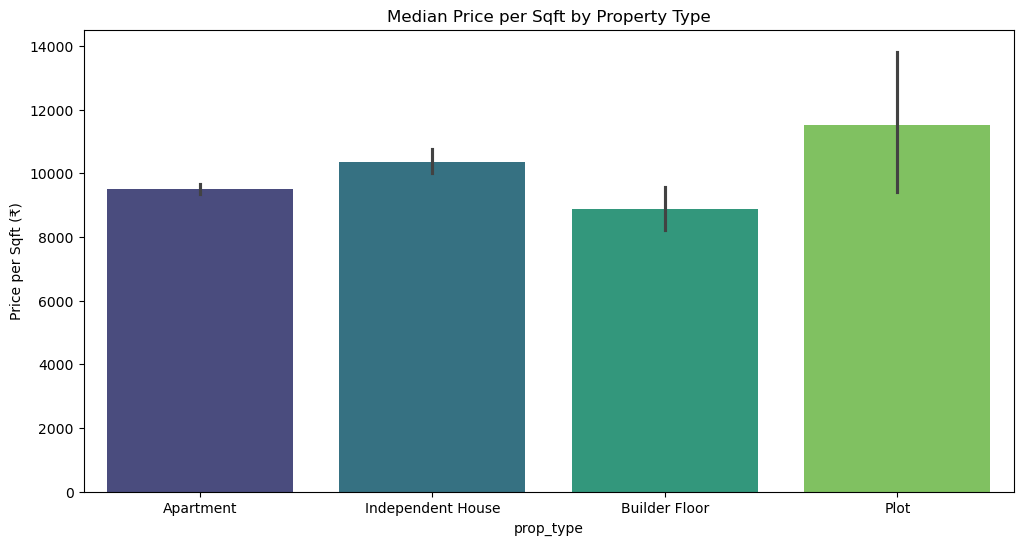

In [90]:
plt.figure(figsize=(12, 6))
# Comparing Price per Sqft across types
sns.barplot(x='prop_type', y='pps', data=df_unique, estimator='median', palette='viridis')
plt.title('Median Price per Sqft by Property Type')
plt.ylabel('Price per Sqft (₹)')
plt.show()

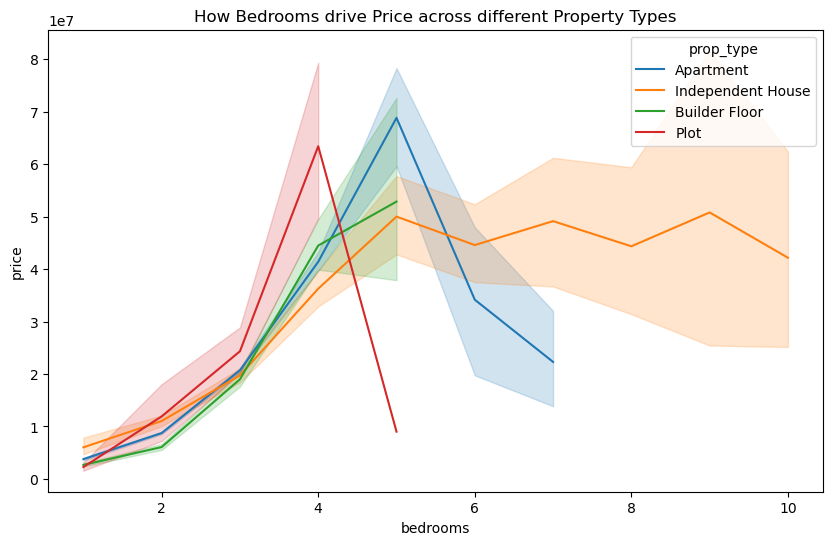

In [91]:
# See if the relationship between Bedrooms and Price changes by Prop_type
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_unique[df_unique['bedrooms'] > 0], x='bedrooms', y='price', hue='prop_type')
plt.title('How Bedrooms drive Price across different Property Types')
plt.show()

In [92]:
# Check counts for the last two important categorical features
print("Furnishing Status:\n", df['furnished'].value_counts())
print("\nFacing Direction:\n", df['facing'].value_counts())

Furnishing Status:
 furnished
Semi-Furnished     5832
Unfurnished        2780
Unknown            1639
Fully-Furnished     287
Name: count, dtype: int64

Facing Direction:
 facing
Unknown       8291
East          2073
North-East      56
North           46
West            23
North-West      15
South-East      14
South           11
South-West       9
Name: count, dtype: int64


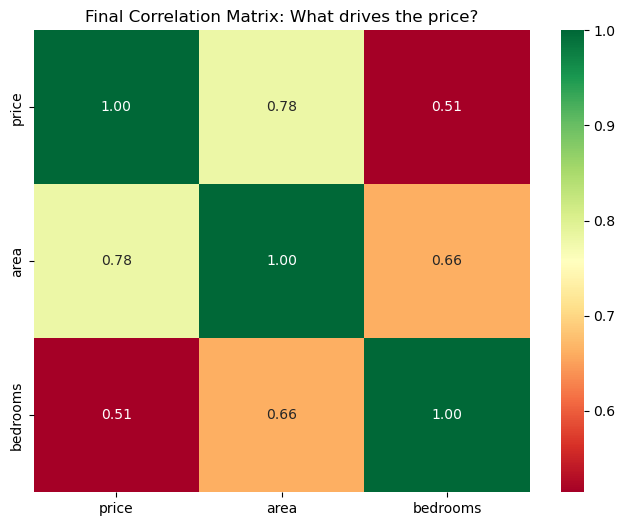

Final Area vs Price Correlation: 0.78


In [103]:
# 4. Correlation Analysis (After Cleaning)
plt.figure(figsize=(8, 6))
correlation_matrix = df[['price', 'area', 'bedrooms']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Final Correlation Matrix: What drives the price?')
plt.show()

print(f"Final Area vs Price Correlation: {correlation_matrix.loc['area', 'price']:.2f}")